In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import timedelta
import sys
import itertools
import cartopy.crs as ccrs
import cartopy.feature as cfeature
land_feature=cfeature.NaturalEarthFeature(category='physical',name='land',scale='50m',facecolor=[0.4,0.6,0.7])
pr1=ccrs.PlateCarree()
from glob import glob
sys.path.insert(0, "..") # This is when you load VirtualFleet functions
from virtualargofleet import Velocity, FloatConfiguration, VirtualFleet

In [3]:
import parcels
parcels.__version__

'3.1.4'

#let's make a June daily clim
files = glob('/home/ref-ocean-reanalysis/MEDSEA_MULTIYEAR_PHY_006_004/med-cmcc-cur-rean-d/*/06/*.nc')
files.sort()
ds = xr.open_mfdataset(files)
dsm = ds.groupby('time.dayofyear').mean()
dsm = dsm.rename({'dayofyear':'time'})
dsm['time'] = xr.DataArray(np.arange('2015-05-31','2015-07-01',dtype='datetime64[D]'), dims=["time"])
dsm.to_netcdf('JuneClim_UV_MEDSEA.nc')

In [4]:
files = glob('data/cmems_glorysInt_octnov_2021.nc')
files.sort()
print(files[0],'\n to \n',files[-1])
ds = xr.open_dataset(files[0])
ds

data/cmems_glorysInt_octnov_2021.nc 
 to 
 data/cmems_glorysInt_octnov_2021.nc


<xarray.Dataset> Size: 263MB
Dimensions:    (time: 47, depth: 50, latitude: 97, longitude: 144)
Coordinates:
  * time       (time) datetime64[ns] 376B 2021-10-15 2021-10-16 ... 2021-11-30
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 388B 15.0 15.08 15.17 ... 22.83 22.92 23.0
  * longitude  (longitude) float32 576B -70.0 -69.92 -69.83 ... -58.17 -58.08
Data variables:
    uo         (time, depth, latitude, longitude) float32 131MB ...
    vo         (time, depth, latitude, longitude) float32 131MB ...
Attributes:
    Conventions:       CF-1.11
    title:             cmems_mod_glo_phy_myint_0.083deg_P1D-m_202311
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_myint_0.083deg_P1D-m_202311
    subset:date:       2025-07-07T13:09:11.305Z

In [5]:
root = "data/cmems_glorysInt_octnov_2021.nc"
#filenames = {'U': root + "/*.nc",
#              'V': root + "/*.nc"}
filenames = {'U': root,
              'V': root}
variables = {'U':'uo', 'V':'vo'}
dimensions = {'time': 'time', 'depth':'depth', 'lat': 'latitude', 'lon': 'longitude'}
VELfield = Velocity(model='custom',
                    src=filenames,
                    variables=variables,
                    dimensions=dimensions)

In [6]:
fieldset = VELfield.fieldset
fieldset.computeTimeChunk(fieldset.U.grid.time[0], 1.)

np.float64(86400.0)

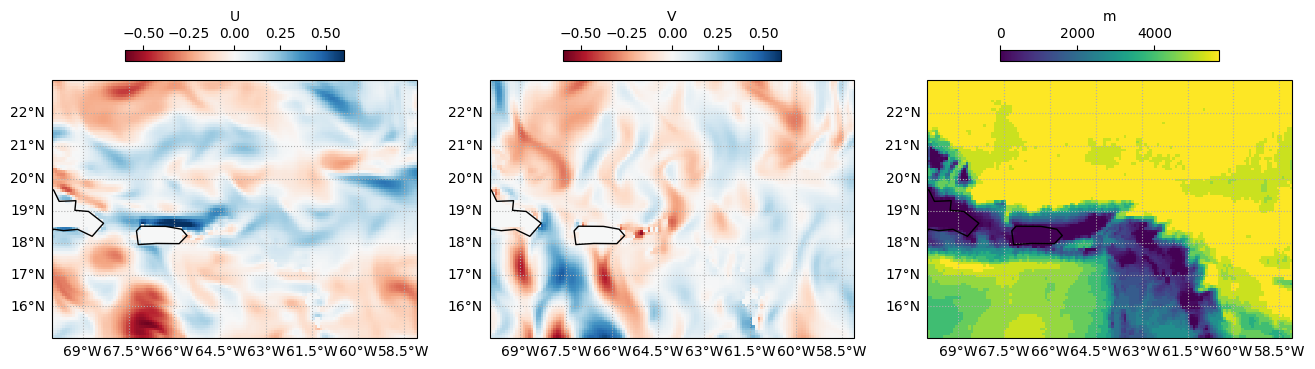

In [8]:
fig=plt.figure(figsize=(16,5))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 3, 1, projection=pr2)
a=ax1.pcolormesh(fieldset.U.grid.lon,fieldset.U.grid.lat,fieldset.U.data[0,0,:-1,:-1],shading='flat',transform=pr1,vmin=-0.6,vmax=0.6,cmap=plt.get_cmap('RdBu'))
ax1.coastlines(resolution='110m',zorder=10)
plt.colorbar(a,location='top',shrink=0.6,label='U')
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1 = fig.add_subplot(1, 3, 2, projection=pr2)
a=ax1.pcolormesh(fieldset.V.grid.lon,fieldset.V.grid.lat,fieldset.V.data[0,0,:-1,:-1],shading='flat',transform=pr1,vmin=-0.6,vmax=0.6,cmap=plt.get_cmap('RdBu'))
ax1.coastlines(resolution='110m',zorder=10)
plt.colorbar(a,location='top',shrink=0.6,label='V')
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1 = fig.add_subplot(1, 3, 3, projection=pr2)
a=ax1.pcolormesh(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,cmap=plt.get_cmap('viridis'),vmin=0)
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
plt.colorbar(a,location='top',shrink=0.6,label='m')

In [9]:
# Set min/max depth for float conf, this is to make sure Parcels doesn't struggle 
min_depth = np.ceil(ds['depth'].min(['depth']).min().values)
max_depth = int(fieldset.gridset.grids[0].depth.max() / 100)*100
print(min_depth,max_depth)

1.0 5700


In [10]:
VELfield.fieldset.add_constant("vf_surface",min_depth)
VELfield.fieldset.add_constant("vf_bottom", max_depth)

In [11]:
mission = FloatConfiguration('default')
mission.update('parking_depth', 4000)
mission.update('profile_depth', 5700)
mission.update('cycle_duration', 4*24)
mission

<FloatConfiguration><default>
- cycle_duration (Maximum length of float complete cycle): 96.0 [hours]
- life_expectancy (Maximum number of completed cycle): 200 [cycle]
- parking_depth (Drifting depth): 4000.0 [m]
- profile_depth (Maximum profile depth): 5700.0 [m]
- vertical_speed (Vertical profiling speed): 0.09 [m/s]

In [12]:
#lon0, lat0 = (-66.402), (19.526)  # Center of the box
#lon0, lat0 = -59.8224, 17.761
lon0, lat0 = -62.5, 19.4

Lx, Ly = 0.2, 0.2 # Size of the box
fbox = [lon0-Lx/2,lat0-Ly/2,lon0+Lx/2,lat0+Ly/2]
coords=np.array(list(itertools.product(np.arange(fbox[0],fbox[2],.025),np.arange(fbox[1],fbox[3],.025))))
lon = coords[:,0]
lat = coords[:,1]
nfloats=len(lon)
dpt = np.linspace(min_depth, min_depth, nfloats) #1m depth
tim = np.array(['2021-11-01' for i in range(nfloats)],dtype='datetime64')
my_plan = {'lat': lat, 
           'lon': lon, 
           'time': tim, 
           'depth':dpt}

In [13]:
my_plan

{'lat': array([19.3  , 19.325, 19.35 , 19.375, 19.4  , 19.425, 19.45 , 19.475,
        19.5  , 19.3  , 19.325, 19.35 , 19.375, 19.4  , 19.425, 19.45 ,
        19.475, 19.5  , 19.3  , 19.325, 19.35 , 19.375, 19.4  , 19.425,
        19.45 , 19.475, 19.5  , 19.3  , 19.325, 19.35 , 19.375, 19.4  ,
        19.425, 19.45 , 19.475, 19.5  , 19.3  , 19.325, 19.35 , 19.375,
        19.4  , 19.425, 19.45 , 19.475, 19.5  , 19.3  , 19.325, 19.35 ,
        19.375, 19.4  , 19.425, 19.45 , 19.475, 19.5  , 19.3  , 19.325,
        19.35 , 19.375, 19.4  , 19.425, 19.45 , 19.475, 19.5  , 19.3  ,
        19.325, 19.35 , 19.375, 19.4  , 19.425, 19.45 , 19.475, 19.5  ,
        19.3  , 19.325, 19.35 , 19.375, 19.4  , 19.425, 19.45 , 19.475,
        19.5  ]),
 'lon': array([-62.6  , -62.6  , -62.6  , -62.6  , -62.6  , -62.6  , -62.6  ,
        -62.6  , -62.6  , -62.575, -62.575, -62.575, -62.575, -62.575,
        -62.575, -62.575, -62.575, -62.575, -62.55 , -62.55 , -62.55 ,
        -62.55 , -62.55 , -62.55 , 

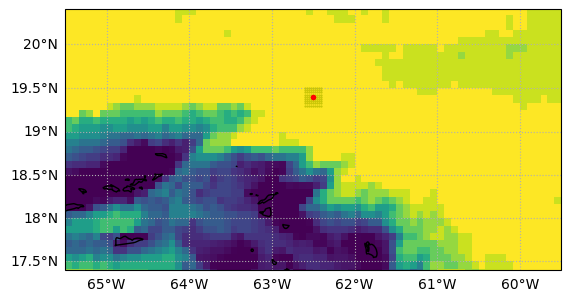

In [15]:
fig=plt.figure()
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 1, 1, projection=pr2)
a=ax1.pcolormesh(fieldset.U.grid.lon,fieldset.U.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,cmap=plt.get_cmap('viridis'),vmin=0)
#b=ax1.contourf(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:,:],np.arange(990,1010),transform=pr1)
ax1.coastlines(resolution='10m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1.plot(my_plan['lon'],my_plan['lat'],'y.',markersize=1,transform=pr1)
ax1.set_extent([lon0-3,lon0+3,lat0-2,lat0+1])
ax1.plot(lon0,lat0,'r.',transform=pr1)

In [16]:
VFleet = VirtualFleet(plan=my_plan, fieldset=VELfield, mission=mission, verbose_events=False)
VFleet

<VirtualFleet>
- 81 floats in the deployment plan
- No simulation performed

In [17]:
VFleet.simulate(
    duration=timedelta(days=15),
    step=timedelta(minutes=5),
    record=timedelta(minutes=60),
    output_folder="data/"
)

/home/kbalem/Bureau/VirtualFleet/knotebooks/../virtualargofleet/virtualargofleet.py:361: UserWarning: Simulation will be saved in : data/m1owu4wx.zarr
  warnings.warn(output_msg)


INFO: Output files are stored in data/m1owu4wx.zarr.
  0%|                                                                                                   | 0/1296000.0 [00:00<?, ?it/s]

/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


  7%|█████▍                                                                            | 86700.0/1296000.0 [00:03<00:50, 23883.93it/s]

/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


...

/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


 93%|██████████████████████████████████████████████████████████████████████████▋     | 1209900.0/1296000.0 [00:53<00:03, 22722.56it/s]

/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/testInstallVF/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|████████████████████████████████████████████████████████████████████████████████| 1296000.0/1296000.0 [00:57<00:00, 22617.12it/s]


<VirtualFleet>
- 81 floats in the deployment plan
- Number of simulation(s): 1
- Last simulation meta-data:
	- Duration: 15d 00h 00m 00s
	- Data recording every: 01h 00m
	- Trajectory file: data/m1owu4wx.zarr
	- Execution time: 00d 00h 01m 01s
	- Executed on: L-BR-LOPS-P26

In [18]:
dout=xr.open_zarr('data/uzp5xskd.zarr')
dout.load()

<xarray.Dataset> Size: 1MB
Dimensions:       (trajectory: 81, obs: 360)
Coordinates:
  * trajectory    (trajectory) int64 648B 747 748 749 750 ... 824 825 826 827
  * obs           (obs) int32 1kB 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
Data variables:
    cycle_age     (trajectory, obs) float32 117kB 300.0 3.9e+03 ... 2.559e+05
    cycle_number  (trajectory, obs) float64 233kB 1.0 1.0 1.0 ... 4.0 4.0 4.0
    cycle_phase   (trajectory, obs) float64 233kB 0.0 0.0 0.0 ... 1.0 1.0 2.0
    lat           (trajectory, obs) float32 117kB 19.3 19.3 19.3 ... 19.7 19.7
    lon           (trajectory, obs) float32 117kB -62.6 -62.6 ... -62.85 -62.85
    time          (trajectory, obs) datetime64[ns] 233kB 2021-11-01 ... 2021-...
    z             (trajectory, obs) float32 117kB 1.0 217.0 ... 4e+03 4.18e+03
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        ArgoParticleArgoFloatKernelAdvectionRK4KeepInWate...
    parcels_mesh:           spherical
    parcels_version:        3.1.2

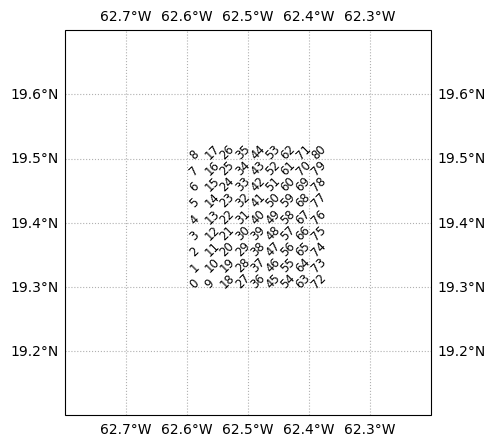

In [19]:
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
fig=plt.figure(figsize=(16,5))
ax1 = fig.add_subplot(projection=pr2)
for i in range(len(dout.trajectory)):
    ax1.text(dout.isel(obs=0)['lon'].values[i],dout.isel(obs=0)['lat'].values[i],
             (dout.isel(obs=0)['trajectory'].values[i] - dout.isel(obs=0)['trajectory'].values[0]).astype('U3'),
             transform=pr1,
             fontsize='small',
             rotation=45.)
ax1.set_extent([lon0-.3,lon0+.3,lat0-.3,lat0+.3])
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)

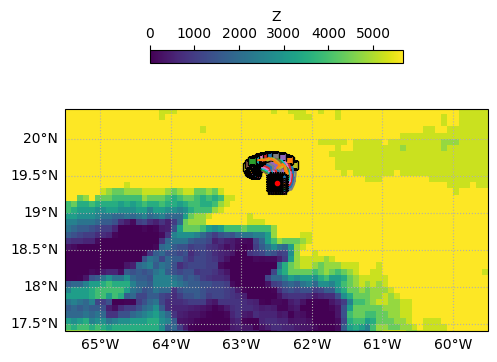

In [21]:
fig=plt.figure(figsize=(12,12))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 2, 1, projection=pr2)
a=ax1.pcolormesh(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,vmin=0,cmap=plt.get_cmap('viridis'))
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
for t in range(len(dout.trajectory.values)):
    ax1.plot(dout['lon'].isel(obs=0,trajectory=t),dout['lat'].isel(obs=0,trajectory=t),'*',markeredgecolor='k',transform=pr1,zorder=10)
    ax1.plot(dout['lon'].isel(trajectory=t),dout['lat'].isel(trajectory=t),transform=pr1)
    ax1.plot(dout['lon'].isel(trajectory=t, obs=-1),dout['lat'].isel(trajectory=t, obs=-1),'s',markeredgecolor='k',transform=pr1)
plt.colorbar(a,location='top',shrink=0.6,label='Z')
ax1.set_extent([lon0-3,lon0+3,lat0-2,lat0+1])
ax1.plot(lon0,lat0,'r.',transform=pr1,zorder=10)

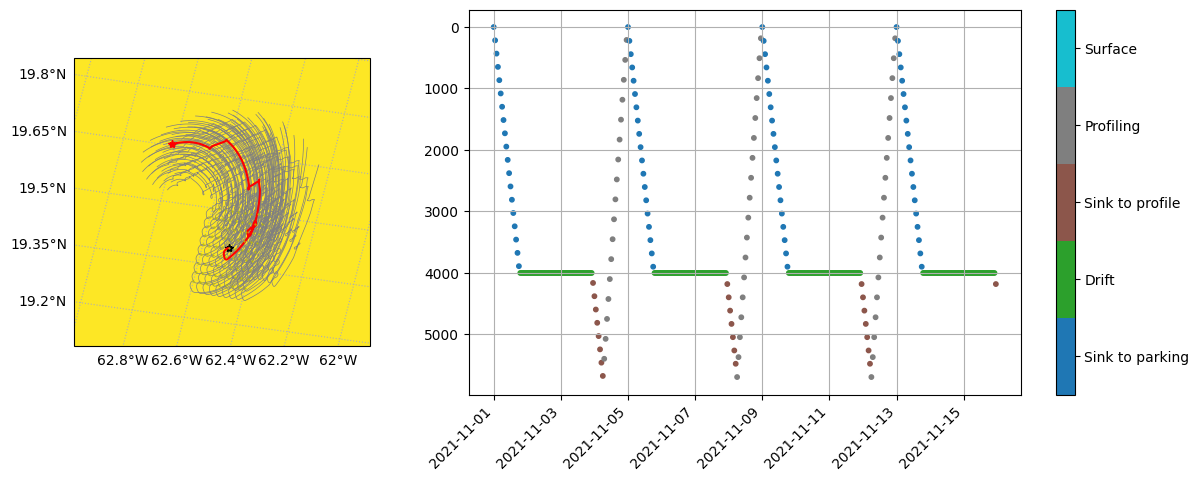

In [22]:
tr=40

fig=plt.figure(figsize=(14,5))
gs = gridspec.GridSpec(1,2,width_ratios=[.6,1.4])
pr1=ccrs.PlateCarree()
pr2=ccrs.LambertAzimuthalEqualArea()
ax1 = fig.add_subplot(gs[0], projection=pr2)
ax1.pcolormesh(fieldset.U.grid.lon,fieldset.U.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,vmin=0,cmap=plt.get_cmap('viridis'))
#ax1.contourf(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:,:],np.arange(990,1010),transform=pr1)
ax1.coastlines(resolution='10m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False

for t in range(len(dout.trajectory.values)):
    ax1.plot(dout['lon'].isel(trajectory=t),dout['lat'].isel(trajectory=t),color='gray',linewidth=0.5,transform=pr1)

ax1.plot(dout['lon'].isel(trajectory=tr,obs=0),dout['lat'].isel(trajectory=tr,obs=0),'k*',transform=pr1)
ax1.plot(dout['lon'].isel(trajectory=tr),dout['lat'].isel(trajectory=tr),'r',transform=pr1)
ax1.plot(dout['lon'].isel(trajectory=tr,obs=-1),dout['lat'].isel(trajectory=tr,obs=-1),'r*',transform=pr1)
extent = [float(dout['lon'].min()-.1),
          float(dout['lon'].max()+.1),
          float(dout['lat'].min()-.1),
          float(dout['lat'].max()+.1)]
ax1.set_extent(extent)
ax1.plot(my_plan['lon'],my_plan['lat'],'y.',markersize=1,transform=pr1)

ax = fig.add_subplot(gs[1])
a=ax.scatter(dout['time'].isel(trajectory=tr),dout['z'].isel(trajectory=tr),s=10,c=dout['cycle_phase'].isel(trajectory=tr),cmap=plt.get_cmap('tab10',5),vmin=0,vmax=5)
ax.invert_yaxis()
_=plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(':')
#ax.set_xlim([np.datetime64('2011-01-15'),np.datetime64('2011-01-16')])
cb=plt.colorbar(a,ticks=[0.5,1.5,2.5,3.5,4.5])
cb.set_ticklabels(['Sink to parking','Drift','Sink to profile','Profiling','Surface'])